<a href="https://colab.research.google.com/github/mattu117117/For-classroom/blob/main/Lecture5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 統計解析演習2025 第5回：周期モデルと地域間相互相関

**対象データ**：豊橋・名古屋・新潟の1時間毎の気象データ（複数年）  
**目標**：
1. 日周期（24h）と年周期（約8760h）を sin/cos で表現し、回帰モデルで当てはめる  
2. 2地点の相互相関（cross-correlation）で先行・遅行関係（lag）を調べる  
3. 名古屋・新潟では多項目（湿度・風速・日射・風向）を加え、予測モデルの妥当性（R²/RMSE）を比較する

## 1. 環境準備（インポート）

In [25]:

import sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

print("Python", sys.version)
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("statsmodels", sm.__version__)


Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas 2.2.2
numpy 2.0.2
statsmodels 0.14.5


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 2. データ読み込み

期待カラム（例）：  
- 共通: `datetime`, `temp_C`, `precip_mm`, `sushine_h`（豊橋）  
- 名古屋/新潟 追加: `solar_MJ_m2`, `wind_m_s`, `humidity_%`  
- 新潟のみ: `wind_direction`（度）

In [27]:
import sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

print("Python", sys.version)
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("statsmodels", sm.__version__)


# ▼ ファイルパスを各自の環境に合わせて修正してください
DATA_PATH = "/content/drive/MyDrive/25StatisticalAnalysisEx./Lecture5/data"

PATH_TOYOHASHI = "toyohashi_hourly_2022-10_to_2025-10_cleaned.csv"
PATH_NAGOYA    = "nagoya_hourly_2022-10_to_2025-10_cleaned.csv"
PATH_NIIGATA   = "niigata_hourly_2022-10_to_2025-10_cleaned.csv"


def load_weather_csv(path, city_name):
    df = pd.read_csv(path)
    df.columns = [c.strip().replace("　", " ").replace(" ", "_") for c in df.columns]
    dt_candidates = [c for c in df.columns if "datetime" in c.lower() or "年月日時" in c]
    if not dt_candidates:
        raise ValueError(f"[{city_name}] datetime 列が見つかりません: {df.columns.tolist()}")
    dt_col = dt_candidates[0]
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce", utc=False)
    df = df.dropna(subset=[dt_col])
    df = df.sort_values(dt_col).drop_duplicates(subset=[dt_col], keep="first")
    df = df.set_index(dt_col).sort_index()
    df.index.name = "datetime"
    for c in df.columns:
        if c != "datetime":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df.attrs["city"] = city_name
    return df

df_t = load_weather_csv(f"{DATA_PATH}/{PATH_TOYOHASHI}", "Toyohashi")
df_n = load_weather_csv(f"{DATA_PATH}/{PATH_NAGOYA}", "Nagoya")
df_g = load_weather_csv(f"{DATA_PATH}/{PATH_NIIGATA}", "Niigata")

print("Toyohashi:", df_t.shape, df_t.index.min(), "→", df_t.index.max())
print("Nagoya   :", df_n.shape, df_n.index.min(), "→", df_n.index.max())
print("Niigata  :", df_g.shape, df_g.index.min(), "→", df_g.index.max())

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas 2.2.2
numpy 2.0.2
statsmodels 0.14.5
Toyohashi: (26328, 4) 2022-10-01 01:00:00 → 2025-10-02 00:00:00
Nagoya   : (26328, 8) 2022-10-01 01:00:00 → 2025-10-02 00:00:00
Niigata  : (26328, 9) 2022-10-01 01:00:00 → 2025-10-02 00:00:00



## 3. 周期特徴量を追加する関数
- t_hour: 開始時刻からの経過時間（時間）
- 日周期（24h）: sin/cos
- 年周期（約8760h）: sin/cos

回帰モデル式

$T_{(t)}=β_0+β_1 \sin(\frac{2πt}{24})+β_2\cos(\frac{2πt}{24})+β_3\sin(\frac{2πt}{8760})+_4\cos(\frac{2πt}{8760})+ε_t$


In [28]:
def add_time_features(df):
    """sin/cosの周期特徴量を追加（24h, 1週, 2週, 1年周期）"""
    df = df.copy()
    start = df.index.min()
    t_hours = (df.index - start) / pd.Timedelta(hours=1)
    df["t_hour"] = t_hours.values

    w_day   = 2*np.pi/24.0
    # 1週間周期 (24h * 7日 = 168h) を追加
    w_week  = 2*np.pi/(24.0 * 7.0)
    # 2週間周期 (24h * 14日 = 336h) を追加
    w_2week = 2*np.pi/(24.0 * 14.0)
    w_year  = 2*np.pi/(365.0*24.0)

    df["sin_day"]   = np.sin(w_day   * df["t_hour"])
    df["cos_day"]   = np.cos(w_day   * df["t_hour"])
    # 1週間周期の特徴量を追加
    df["sin_week"]  = np.sin(w_week  * df["t_hour"])
    df["cos_week"]  = np.cos(w_week  * df["t_hour"])
    # 2週間周期の特徴量を追加
    df["sin_2week"] = np.sin(w_2week * df["t_hour"])
    df["cos_2week"] = np.cos(w_2week * df["t_hour"])
    df["sin_year"]  = np.sin(w_year  * df["t_hour"])
    df["cos_year"]  = np.cos(w_year  * df["t_hour"])

    return df

## 4. モデルの学習と予測、可視化をする関数

In [29]:
def fit_and_forecast(df, target="temp_C", base_terms=None, extra_terms=None,
                     train_start=None, train_end=None, test_start=None, test_end=None):
    """指定期間で学習し、次に指定した期間を予測"""
    if base_terms is None:
        base_terms = ["sin_day","cos_day","sin_year","cos_year"]
    if extra_terms is None:
        extra_terms = []

    df = add_time_features(df)
    cols = [c for c in base_terms if c in df.columns] + [c for c in extra_terms if c in df.columns]
    dfm = df.dropna(subset=[target] + cols).copy()

    # 教師データの期間、テストデータの期間の設定
    train = dfm.loc[train_start:train_end]
    test  = dfm.loc[test_start:test_end]

    # 定数項（切片）の追加
    X_tr = sm.add_constant(train[cols])
    y_tr = train[target]
    X_te = sm.add_constant(test[cols])
    y_te = test[target]

    # 最小二乗法（Ordinary Least Squares)
    model = sm.OLS(y_tr, X_tr).fit()

    pred_train = pd.Series(model.predict(X_tr), index=train.index, name="pred_train")
    pred_test  = pd.Series(model.predict(X_te), index=test.index,  name="pred_test")

    r2 = r2_score(y_te, pred_test)
    rmse = math.sqrt(mean_squared_error(y_te, pred_test))

    return {
        "model": model,
        "r2": r2,
        "rmse": rmse,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train": train,
        "test": test
    }

def plot_forecast(result, city, target="temp_C"):
    """予測結果の可視化"""
    train = result["train"]
    test = result["test"]
    pred_train = result["pred_train"]
    pred_test = result["pred_test"]
    r2, rmse = result["r2"], result["rmse"]

    plt.figure(figsize=(10,4))
    plt.plot(train.index, train[target], label="Train actual", alpha=0.6)
    plt.plot(train.index, pred_train, label="Train fit", alpha=0.6)
    plt.plot(test.index, test[target], label="Test actual", color="black")
    plt.plot(test.index, pred_test, label="Prediction", color="red")
    plt.axvline(x=train.index.max(), color="gray", linestyle="--", alpha=0.7)
    plt.title(f"{city}: R²={r2:.3f}, RMSE={rmse:.2f}")
    plt.xlabel("Datetime")
    plt.ylabel(target)
    plt.legend()
    plt.show()

## 5. 都市ごとにある期間の気温変化を学習し、次の期間の気温変化を予測する

=== 予測対象: Nagoya (Train: 2025-06-01〜2025-07-31, Test: 2025-08-01〜2025-08-31) ===

=== Model 1 (Base) ===


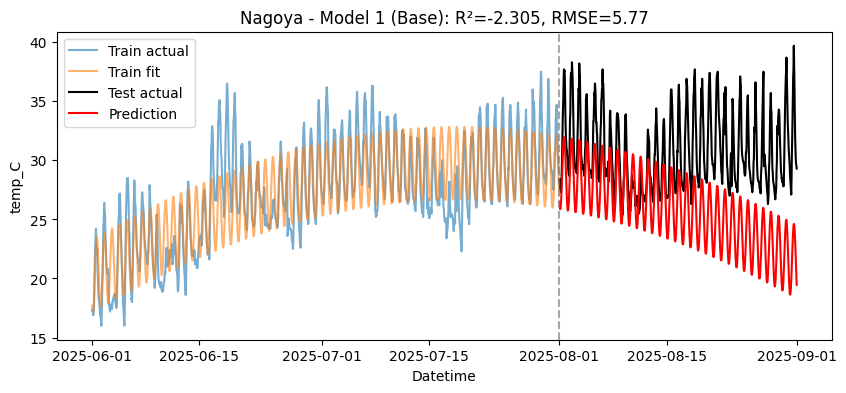


=== Model 2 (Add Weeks) ===


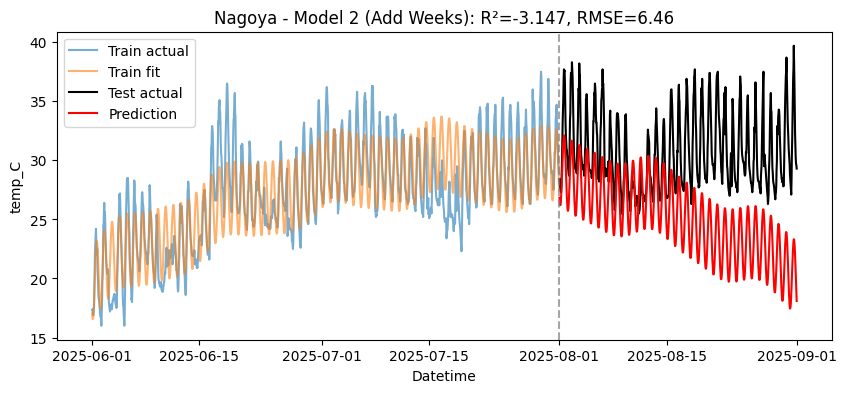


=== Model 3 (Week + Weather) ===


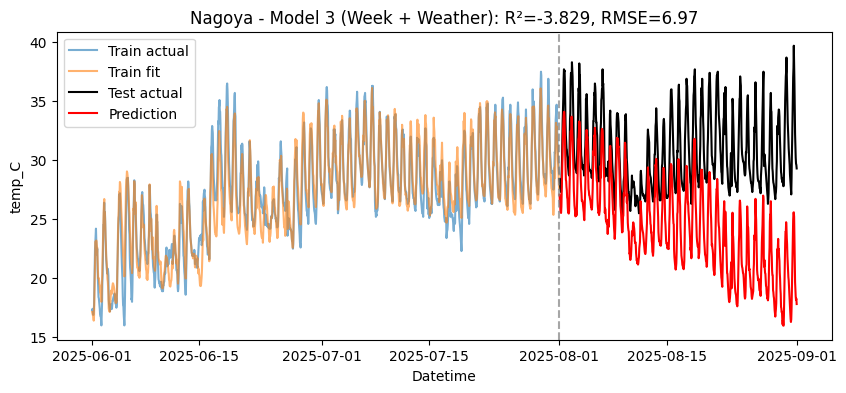


=== 課題1：モデル精度比較 (テスト期間) ===


,R²,RMSE,説明変数(Base),説明変数(Extra)
Model,,,,
Model 1 (Base),-2.305116,5.770476,"sin_day, cos_day, sin_year, cos_year",None
Model 2 (Add Weeks),-3.146921,6.463699,"sin_day, cos_day, sin_week, cos_week, sin_2wee...",None
Model 3 (Week + Weather),-3.828583,6.974741,"sin_day, cos_day, sin_week, cos_week, sin_2wee...","humidity_%, wind_m_s, solar_MJ_m2"


In [30]:
# --- 1. 学習・テスト期間の設定 (学習: 2ヶ月, テスト: 1ヶ月) ---
# train_start, train_end = "2024-12-01", "2024-12-31" # 元の期間 (コメントアウト)
# test_start,  test_end  = "2025-01-01", "2025-01-31" # 元の期間 (コメントアウト)

train_start, train_end = "2025-06-01", "2025-07-31"
test_start,  test_end  = "2025-08-01", "2025-08-31"

# --- 2. 比較するモデルの定義 (名古屋データ df_n を使用) ---
# add_time_features はセル3で改良済みのものを使用
# df_t, df_n, df_g はセル2で読み込み済みと仮定

# 比較対象の都市 (温度以外の項目がある名古屋を選択)
city_df = df_n
city_name = "Nagoya"

# モデル1: 基本の周期特徴量 (Lecture5 のデフォルト)
base_terms_v1 = ["sin_day", "cos_day", "sin_year", "cos_year"]
extras_v1 = []

# モデル2: 1週・2週周期を追加 (課題アイデア1)
base_terms_v2 = ["sin_day", "cos_day", "sin_week", "cos_week", "sin_2week", "cos_2week", "sin_year", "cos_year"]
extras_v2 = []

# モデル3: 1週・2週周期 + 他の気象項目 (課題アイデア2)
base_terms_v3 = base_terms_v2
extras_v3 = ["humidity_%", "wind_m_s", "solar_MJ_m2"] # Lecture4と同様に他の変数を投入

# 比較するモデルを辞書に格納
models_to_compare = {
    "Model 1 (Base)": (base_terms_v1, extras_v1),
    "Model 2 (Add Weeks)": (base_terms_v2, extras_v2),
    "Model 3 (Week + Weather)": (base_terms_v3, extras_v3)
}

results = {}
summary = []

print(f"=== 予測対象: {city_name} (Train: {train_start}〜{train_end}, Test: {test_start}〜{test_end}) ===")

# --- 3. 各モデルの実行と比較 ---
for model_name, (base_terms, extras) in models_to_compare.items():
    print(f"\n=== {model_name} ===")

    # fit_and_forecast 関数 (セル4で定義済み) を使用
    result = fit_and_forecast(
        city_df,
        target="temp_C",
        base_terms=base_terms,
        extra_terms=extras,
        train_start=train_start,
        train_end=train_end,
        test_start=test_start,
        test_end=test_end
    )

    results[model_name] = result
    summary.append({
        "Model": model_name,
        "R²": result["r2"],
        "RMSE": result["rmse"],
        "説明変数(Base)": ", ".join(base_terms),
        "説明変数(Extra)": ", ".join(extras) if extras else "None"
    })

    # 予測結果の可視化 (セル4で定義済み)
    plot_forecast(result, f"{city_name} - {model_name}", target="temp_C")

# --- 4. 結果のサマリー ---
print("\n=== 課題1：モデル精度比較 (テスト期間) ===")
summary_df = pd.DataFrame(summary).set_index("Model")
display(summary_df)


## 6. 都市間の相互相関（温度・残差）
- 対称ラグ範囲 [-48, 48]（±2日）で評価  
- 正のラグ: 第2系列が遅れて変動 / 負のラグ: 第1系列が遅れて変動


=== 豊橋 ↔ 名古屋 ===


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


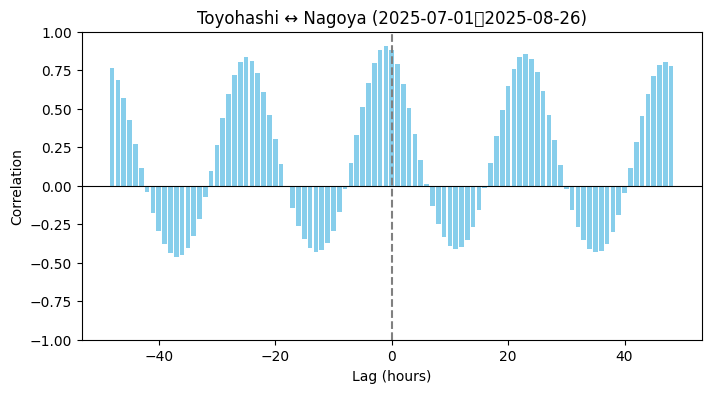

最大相関 = 0.910 （lag = -1 時間）
=== 豊橋 ↔ 新潟 ===


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12316 (\N{WAVE DASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


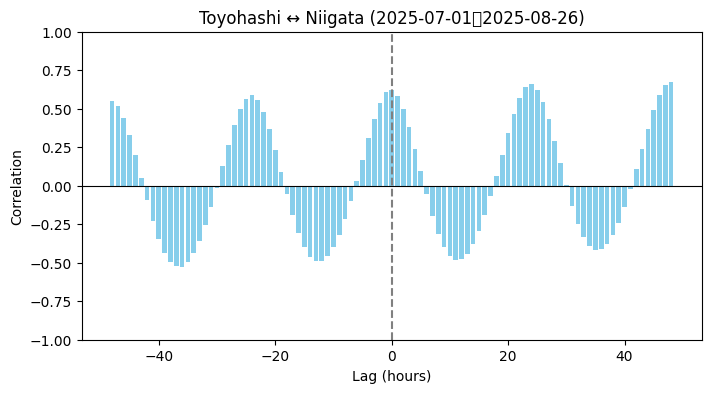

最大相関 = 0.671 （lag = 48 時間）


In [31]:
# 分析する期間を指定
start, end = "2025-07-01", "2025-08-26"

# 豊橋・名古屋・新潟データの期間を切り出す
t_sub = df_t.loc[start:end, "temp_C"]
n_sub = df_n.loc[start:end, "temp_C"]
g_sub = df_g.loc[start:end, "temp_C"]

def cross_correlation(a, b, max_lag=48, title="Cross-correlation",ylim=(-1, 1), xlim=None):
    """
    2系列の相互相関を計算・可視化する関数
    max_lag: ±max_lag 時間（例：72=3日）まで
    """
    # 同じ時刻のみに揃える
    df = pd.concat([a, b], axis=1).dropna()
    a_aligned = df.iloc[:,0]
    b_aligned = df.iloc[:,1]

    lags = np.arange(-max_lag, max_lag+1)
    corrs = [a_aligned.corr(b_aligned.shift(l)) for l in lags]

    plt.figure(figsize=(8,4))
    plt.bar(lags, corrs, width=0.8, color="skyblue")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="gray", linestyle="--")
    plt.title(title)
    plt.xlabel("Lag (hours)")
    plt.ylabel("Correlation")

    # --- 軸の固定 ---
    if ylim is not None:
        plt.ylim(ylim)
    if xlim is not None:
        plt.xlim(xlim)

    plt.show()

    max_idx = np.argmax(corrs)
    print(f"最大相関 = {corrs[max_idx]:.3f} （lag = {lags[max_idx]} 時間）")
    return pd.Series(corrs, index=lags, name="correlation")


# --- 相互相関の計算 ---
print("=== 豊橋 ↔ 名古屋 ===")
ccf_tn = cross_correlation(t_sub, n_sub,
                           max_lag=48,
                           title=f"Toyohashi ↔ Nagoya ({start}〜{end})")

print("=== 豊橋 ↔ 新潟 ===")
ccf_tg = cross_correlation(t_sub, g_sub,
                           max_lag=48,
                           title=f"Toyohashi ↔ Niigata ({start}〜{end})")


## 7. 地域間予想モデル：　ある都市の気温で別の都市の気温を予測

多変量回帰モデル式

$T_{Toyohashi} (t)=a_0+a_1 T_{Niigata}(t-τ_1)+a_2 T_{Nagoya}(t-τ_2)+ε_t $

名古屋の最適lag = -1h, 新潟の最適lag = 24h


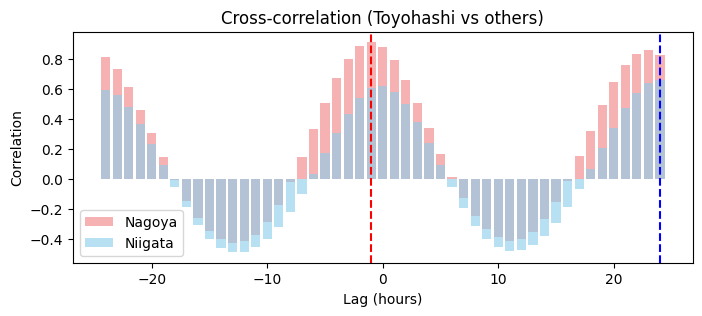

                            OLS Regression Results                            
Dep. Variable:            T_toyohashi   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     1255.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:47:15   Log-Likelihood:                -1756.0
No. Observations:                1343   AIC:                             3526.
Df Residuals:                    1336   BIC:                             3562.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              11.9509      0.831     

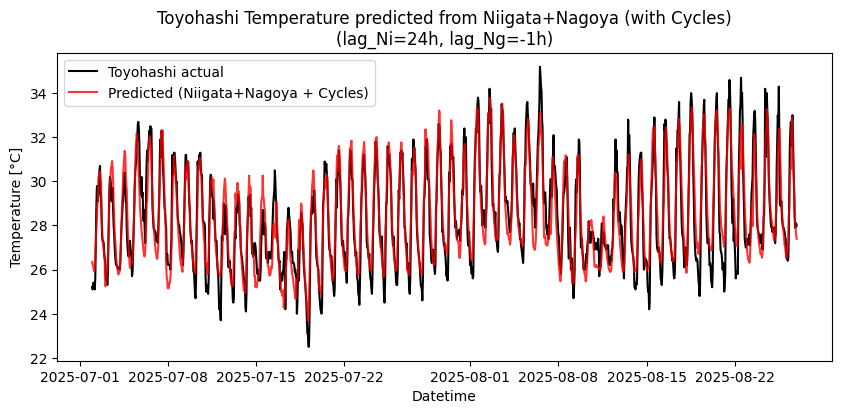

In [33]:
# ==== 1. 対象期間 ====\n",
start, end = "2025-07-01", "2025-08-26"

# 気温データを取得
toyohashi_temp = df_t.loc[start:end, "temp_C"]
nagoya_temp    = df_n.loc[start:end, "temp_C"]
niigata_temp   = df_g.loc[start:end, "temp_C"]

# ==== 2. 相互相関（最適ラグ）の確認 ====\n",
# find_best_lag 関数 (セル7で定義済み) を使用
def find_best_lag(a, b, max_lag=24):
    lags = np.arange(-max_lag, max_lag+1)
    corrs = [a.corr(b.shift(l)) for l in lags]
    best = lags[np.argmax(corrs)]
    return best, corrs

lag_ng, corr_ng = find_best_lag(toyohashi_temp, nagoya_temp)
lag_ni, corr_ni = find_best_lag(toyohashi_temp, niigata_temp)
print(f"名古屋の最適lag = {lag_ng}h, 新潟の最適lag = {lag_ni}h")

# 可視化（参考）
plt.figure(figsize=(8,3))
plt.bar(np.arange(-24,25), corr_ng, color="lightcoral", alpha=0.6, label="Nagoya")
plt.bar(np.arange(-24,25), corr_ni, color="skyblue", alpha=0.6, label="Niigata")
plt.axvline(lag_ng, color="red", linestyle="--")
plt.axvline(lag_ni, color="blue", linestyle="--")
plt.legend(); plt.title("Cross-correlation (Toyohashi vs others)")
plt.xlabel("Lag (hours)"); plt.ylabel("Correlation")
plt.show()

# ==== 3. 回帰用データ作成 (改良版) ====\n",

# --- 豊橋のデータに周期特徴量を追加 ---
# add_time_features 関数 (セル3で定義済み、1週間周期はあってもなくても良い)
df_t_features = add_time_features(df_t.loc[start:end])

# 豊橋の目的変数 (Y)
y_df = df_t_features[["temp_C"]].rename(columns={"temp_C": "T_toyohashi"})

# 豊橋の周期特徴量 (X1) ※基本の日周期と年周期のみ追加
toyohashi_cycles = df_t_features[["sin_day", "cos_day", "sin_year", "cos_year"]]

# 他都市のラグ付き気温 (X2, X3)
nagoya_lagged = nagoya_temp.shift(lag_ng).rename(f"T_nagoya_lag{lag_ng}")
niigata_lagged = niigata_temp.shift(lag_ni).rename(f"T_niigata_lag{lag_ni}")

# 全データを結合 (Y と X1, X2, X3)
dfm = pd.concat([
    y_df,
    nagoya_lagged,
    niigata_lagged,
    toyohashi_cycles  # 豊橋の周期特徴量を追加
], axis=1).dropna()

# ==== 4. 多変量回帰モデル (改良版) ====\n",
# Lecture4 (TODO-2, 3) と同じ sm.OLS を使用
target = "T_toyohashi"
predictors = [col for col in dfm.columns if col != target] # Y以外のすべてをXとする

X = sm.add_constant(dfm[predictors])
y = dfm[target]

model = sm.OLS(y, X).fit()
print(model.summary())

# ==== 5. 予測・評価 (改良版) ====\n",
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = math.sqrt(mean_squared_error(y, y_pred))
# R2とRMSEの表示精度を小数点4桁に変更
print(f"\nR² = {r2:.4f}, RMSE = {rmse:.4f}\n")

# ==== 6. 可視化 (改良版) ====\n",
plt.figure(figsize=(10,4))
plt.plot(dfm.index, y, label="Toyohashi actual", color="black")
# 凡例とタイトルを分かりやすく変更
plt.plot(dfm.index, y_pred, label="Predicted (Niigata+Nagoya + Cycles)", color="red", alpha=0.8)
plt.title(f"Toyohashi Temperature predicted from Niigata+Nagoya (with Cycles)\n(lag_Ni={lag_ni}h, lag_Ng={lag_ng}h)")
plt.xlabel("Datetime")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.show()


## 8. 課題：　回帰モデルの改良

# 課題１ （３．４．５.を改良）

1つの都市について、ある期間（1週間～3カ月）の気温を学習し、その後の期間（1週間～3カ月）の気温変化を予測してください。現状では、あまりよい予測ができているとは言えないので、次のようなアイデアを実装し、よりよい予測を行ってください。

- 1週間周期、2週間周期などを取り入れる
- 温度以外の使える項目、を利用する

# 課題２ （７．を改良）
地域間予想モデルで、新たな項目を付けくわえるなどして、より良い予測を行ってください。


注１：解答方法　グラフ等をキャプチャ、しwordなどに張り付け、適宜説明を加えて、PDFの形で提出する。

注：　課題１と課題２を合わせて、A4で2ページに収まるようにレポートを作成してください。
